In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.data.datasets.msd import MsdDataset, SparseGraphToSceneGraphDecoder


ds = MsdDataset(which_dataset="manh_small_3000")


/home/dkm/.conda/envs/ifh-gen/lib/python3.11/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/dkm/.conda/envs/ifh-gen/lib/python3.11/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: Module src was already imported from None, but /app is being added to sys.path
  import pkg_resources
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<int, std::allocator<int> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<double, std::allocator<double> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vect

Using root path: datasets/ssg/manh_small_3000
Loaded 2400 pairs from datasets/ssg/manh_small_3000/raw/ssg_manhattan_small_3000.pkl


/home/dkm/.conda/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/data/dataset.py:240: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  warnings.warn(
/home/dkm/.conda/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "
/home/dkm/.conda/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InM

In [3]:
g = ds[2]
g.x.argmax(-1)

tensor([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 3])

In [4]:
from src.datatypes.sparse import SparseGraph
import torch
import numpy as np
def sgh_proximity_permutation(datapoint: SparseGraph, n: int, start_from_furthest: bool = True) -> np.ndarray:

    removal_hierarchy = {"permanent": torch.Tensor([0]), "order": torch.Tensor([2, 1, 3])}

    datapoint = datapoint.clone().collapse()
    
    order = torch.zeros(datapoint.num_nodes, dtype=torch.int32)
    curr_idx = 0
    center = datapoint.node_pos.mean(dim=0, keepdim=True)
    
    for i in range(removal_hierarchy["order"].shape[0]):
        nodes_of_type = (datapoint.x == removal_hierarchy["order"][i]).nonzero(as_tuple=True)[0]
        if len(nodes_of_type) > 0:
            if start_from_furthest: # pick starting node
                starting_node_idx = torch.argmax(torch.cdist(center, datapoint.node_pos[nodes_of_type]))
                starting_node = nodes_of_type[starting_node_idx]
            else:
                starting_node = nodes_of_type[0]
            distances = torch.cdist(datapoint.node_pos[starting_node].unsqueeze(0), datapoint.node_pos[nodes_of_type])
            ordered_nodes = torch.argsort(distances, dim=1).squeeze(0)
            order[nodes_of_type[ordered_nodes]] = curr_idx + torch.arange(len(ordered_nodes), dtype=torch.int32)
            curr_idx += len(ordered_nodes)
                
    for i in range(removal_hierarchy["permanent"].shape[0]):
        nodes_of_type = (datapoint.x == removal_hierarchy["permanent"][i]).nonzero(as_tuple=True)[0]
        order[nodes_of_type] = -1
                
    return np.array(order, dtype=np.int32)


In [5]:
from src.noise.removal import sgh_permutation, bfs_permutation
g = ds[9]
display(g.x.argmax(-1))
display(sgh_proximity_permutation(g, g.num_nodes))
display(sgh_permutation(g, g.num_nodes))
display(bfs_permutation(g, g.num_nodes))

tensor([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2,
        3])

array([ 6,  5,  4,  7, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1,  2,  3,  0,  1,  8], dtype=int32)

array([ 4,  5,  7,  6, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1,  0,  2,  1,  3,  8], dtype=int32)

(array([ 1, 20, 23, 24,  2,  3,  0,  4, 13,  5,  6,  7, 14, 15,  8,  9, 16,
        10, 11, 17, 19, 21, 18, 22, 12], dtype=int32),
 {'node_depth': array([1, 2, 2, 2, 1, 1, 0, 1, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2,
         2, 2, 2], dtype=int32)})

In [6]:
from src.noise.removal import PermutationRemovalProcess, CategoricalNodesSchedule, CategoricalGshNodesSchedule

removal = PermutationRemovalProcess(
    schedule=CategoricalGshNodesSchedule([1], map=[0,2,3,1]),
    permutation_type='scene_graph_proximity'
)

In [7]:
from torch_geometric.loader import DataLoader

def proc_data(g):
    removal.prepare_data(g)
    return g

g_list = [ds[9]]
# Suppose `dataset` is a list or a PyG Dataset of `Data` objects:
loader = DataLoader(g_list, batch_size=1, shuffle=True)
g0 = next(iter(loader))
print(g0.batch)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0])


In [8]:
# get data and prepare for removal process
# involves precomputing the removal order and adding it as a node attribute
#g0 = ds[10]
removal.prepare_data(g0)
print('removal order:', g0.node_perm.long())
# print('removable nodes:', f'{g0.global_n0.item()}/{g0.num_nodes_per_sample}')

removal order: tensor([ 6,  5,  4,  7, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1,  2,  3,  0,  1,  8])


In [9]:
print(g0.x)
print(g0.batch)
g0.global_n0_per_type

tensor([[0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0])


tensor([[0, 1, 4, 4]])

In [10]:
# this is the number of removal steps, computed from the removal schedule
# which is defined by the block sizes and block choice algorithm
num_remv_steps = removal.get_max_time(n0=g0.global_n0, data=g0)
num_remv_steps = 10

# iterate through the removal process
# n0 is the original number of nodes, useful sometimes for computing the schedule
# different iterations can have different removal sequences (due to randomness)
seq = [g0]
gt = g0
gt.node_idx = torch.arange(gt.num_nodes, dtype=torch.int64)
print(gt.global_n0_per_type)
for t in range(num_remv_steps):
    gt = removal.sample_next(gt, t=t+1, n0=g0.global_n0)
    seq.append(gt)

tensor([[0, 1, 4, 4]])


In [11]:
g0.node_perm

tensor([ 6,  5,  4,  7, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1,  2,  3,  0,  1,  8], dtype=torch.int32)

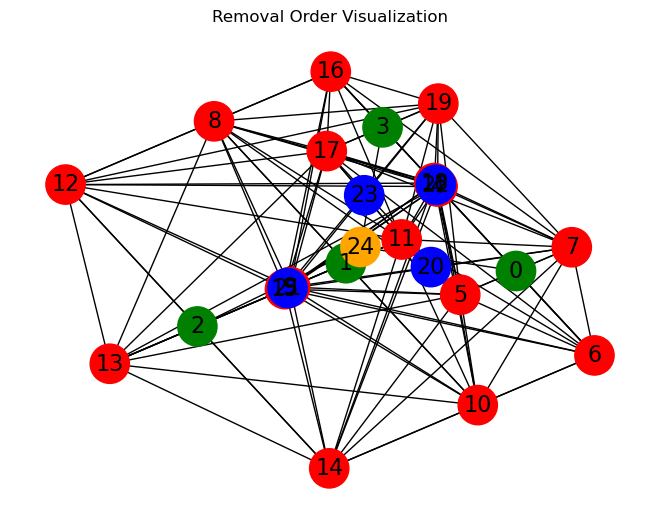

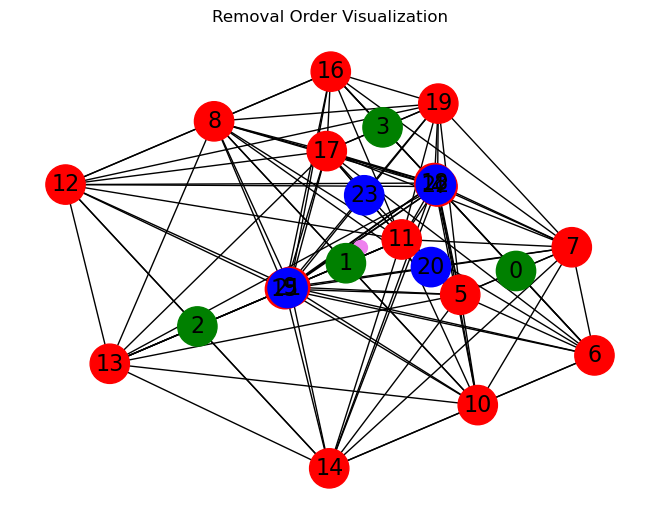

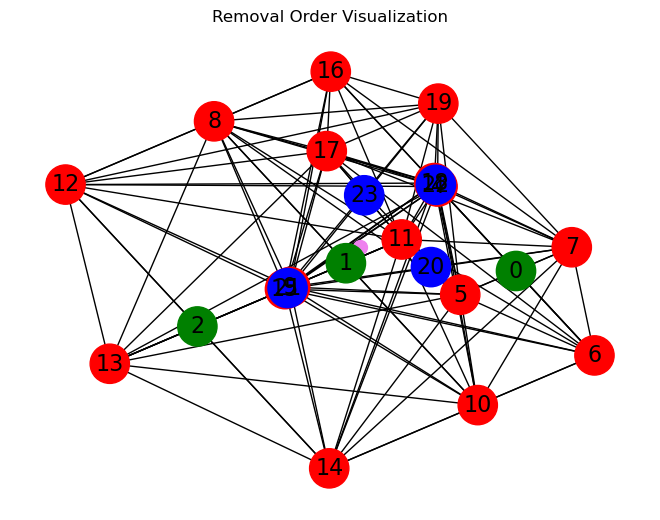

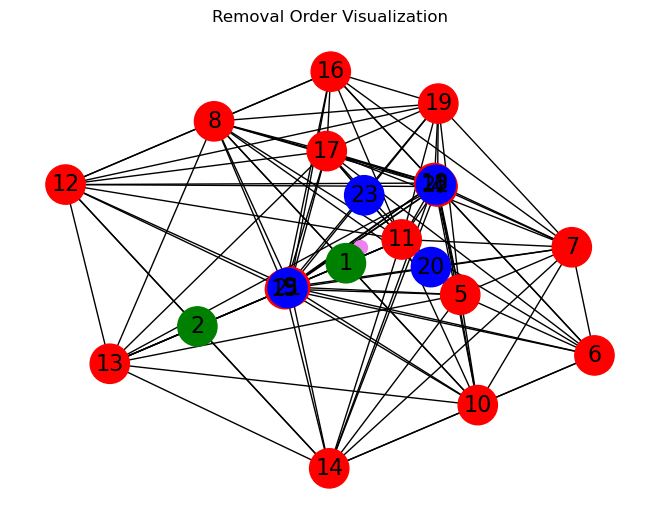

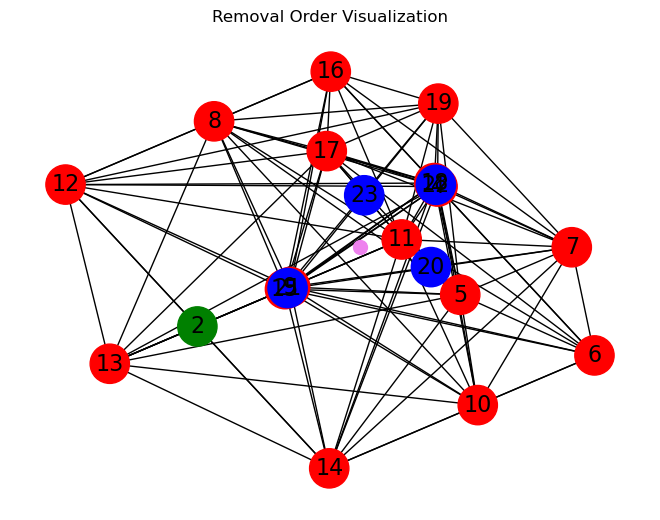

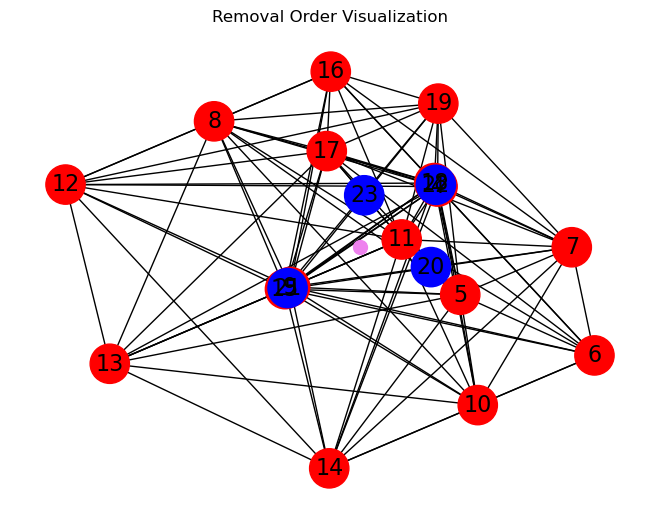

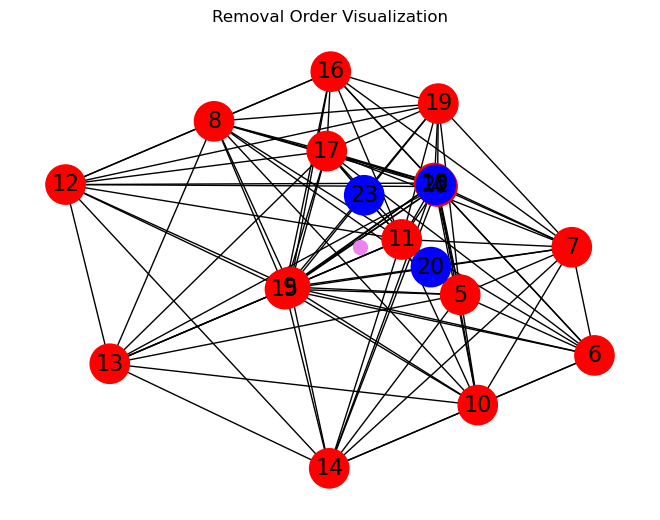

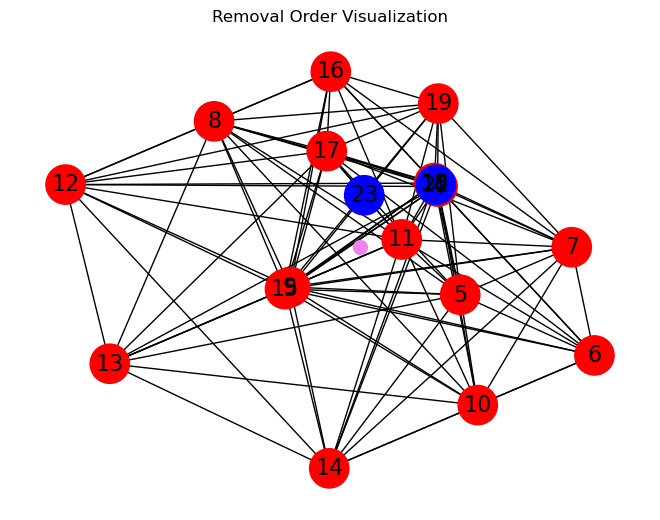

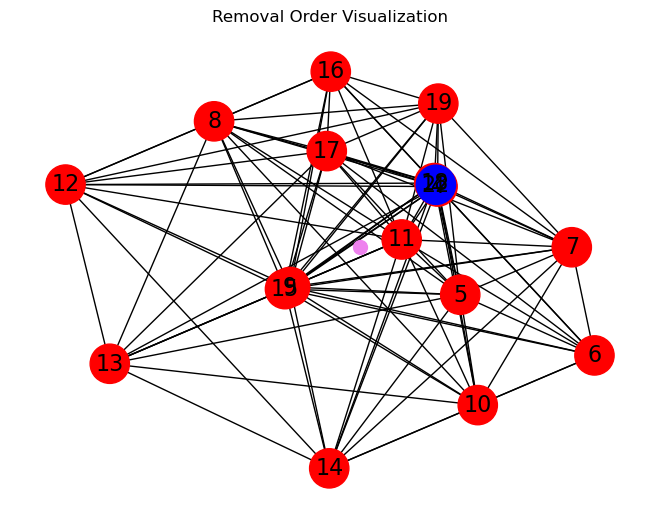

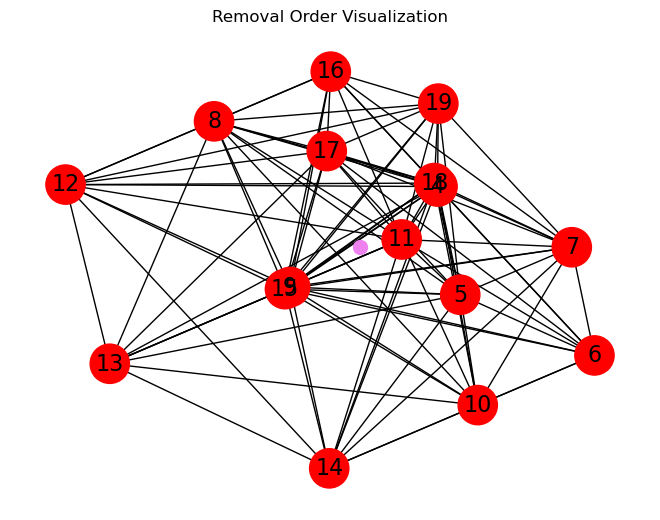

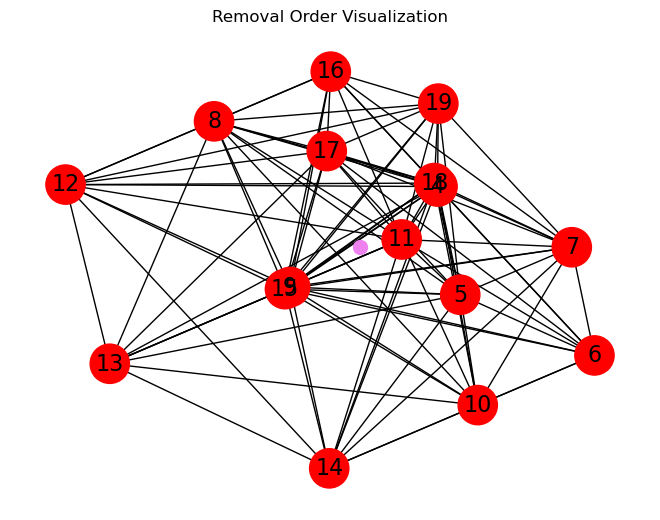

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

colors = [
    'red',
    'green',
    'blue',
    'orange'
]

#compute middle position of nodes
center = gt.node_pos.mean(dim=0, keepdim=True)

for g_t in seq:
    g = to_networkx(g_t, to_undirected=True)
    #pos = nx.spring_layout(g)
    color = [colors[i] for i in g_t.x.argmax(-1).tolist()]
    pos = {i: g_t.node_pos[i, :2] for i in range(g_t.num_nodes)}
    labels = {i: str(g_t.node_idx[i].item()) for i in range(g_t.num_nodes)}
    nx.draw(g, node_color=color, node_size=800, font_size=14, pos=pos)
    # labels = {i: str(removal_order[i]) for i in range(len(removal_order))}
    # labels = {i: str(removal_order[i]) for i in range(len(removal_order))}
    nx.draw_networkx_labels(g, pos, font_size=16, font_color='black', labels=labels)
    # display center
    plt.scatter(center[0, 0].item(), center[0, 1].item(), color='violet', s=100, label='Center')
    plt.title("Removal Order Visualization")
    plt.show()